# Exercise 5
**Cristina Correa - 1819211867**


In this exercise we will be using a simple ANN for the regression task and
compare its performance to the MLP model.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from keras.layers import Input
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [19]:
# Load the California housing dataset
california_housing = fetch_california_housing()
data = pd.DataFrame(
    data=np.c_[california_housing["data"], california_housing["target"]],
    columns=california_housing["feature_names"] + ["target"],
)

In [20]:
# Select features and target variable
X = data.drop("target", axis=1)
y = data["target"]

In [21]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardise the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# Build the neural network model
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))  
model.add(Dense(units=512, activation="relu"))
model.add(Dense(units=1, activation="linear"))

# Compile the model
model.compile(optimizer="adam", loss="mean_squared_error")

In [24]:
# Train the model
model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_scaled, y_test),
    verbose=1,
)

Epoch 1/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.1485 - val_loss: 0.5983
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5324 - val_loss: 0.4634
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4328 - val_loss: 0.4130
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4044 - val_loss: 0.3932
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4187 - val_loss: 0.3851
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3808 - val_loss: 0.3765
Epoch 7/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3602 - val_loss: 0.3679
Epoch 8/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3685 - val_loss: 0.3624
Epoch 9/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3618 - val_loss: 0.3733
Epoch 10/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3573 - val_loss: 0.3515
Epoch 11/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3467 - val_loss: 0.3471
Epoch 12/100
129/129 ━━━━━━━━━━━━━━━━━━━━

In [25]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [26]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 0.532280559907773


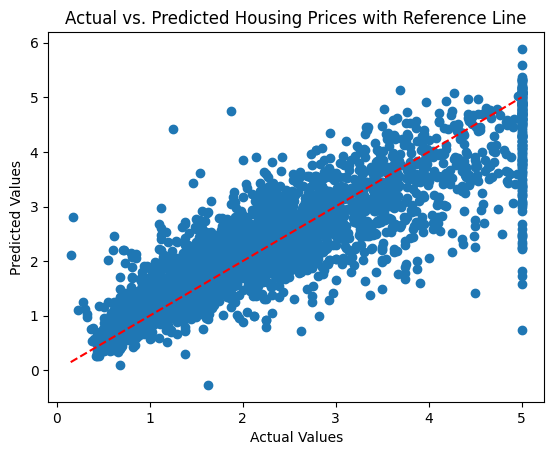

In [27]:
plt.plot(
    [min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle="--", color="red"
)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Housing Prices with Reference Line")
plt.show()